# Prediksi Bank Customer Churn menggunakan KNN dan Regresi Logistik

Notebook ini bertujuan untuk memprediksi apakah seorang nasabah bank akan berhenti berlangganan (churn) atau tidak. Kita akan melakukan Eksplorasi Data (EDA), Pemrosesan Awal Data (Preprocessing), dan membandingkan dua algoritma: K-Nearest Neighbors (KNN) dan Regresi Logistik.

In [2]:
# Import library dasar yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import library dari scikit-learn untuk machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Memuat Dataset
Kita akan memuat dataset. Pastikan nama file CSV sesuai dengan yang Anda unduh dari Kaggle (biasanya bernama `Bank Customer Churn Prediction.csv` atau `Churn_Modelling.csv`).

In [3]:
# Ganti nama file ini dengan nama file CSV asli yang Anda miliki
df = pd.read_csv("datasets/bank_churn.csv")

# Menampilkan 5 baris pertama data
display(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'datasets/bank_churn.csv'

## 2. Exploratory Data Analysis (EDA)
Tujuan EDA adalah memahami karakteristik data, mengecek nilai yang hilang (missing values), dan melihat korelasi antar fitur.

In [3]:
# Mengecek informasi dataset (tipe data dan missing values)
print("Informasi Dataset:")
df.info()
print("\n--------------------------\n")

# Mengecek duplikasi data
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

# Statistik deskriptif untuk kolom numerik
display(df.describe())

Informasi Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  str    
 3   gender            10000 non-null  str    
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB

--------------------------

Jumlah baris duplikat: 0


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Visualisasi Distribusi Target (Churn)
Mari kita lihat keseimbangan kelas target kita. Dataset churn biasanya tidak seimbang (imbalanced), di mana jumlah nasabah yang *tidak churn* jauh lebih banyak.

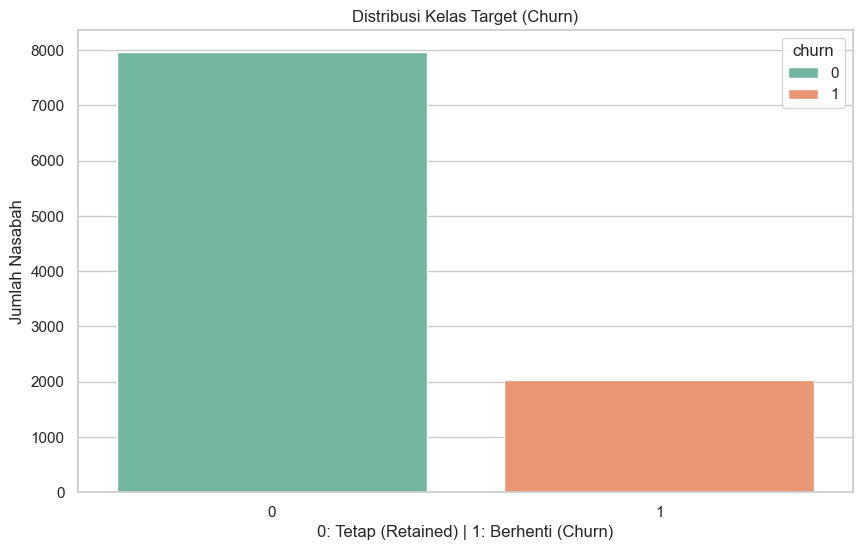

churn
0    79.63
1    20.37
Name: proportion, dtype: float64


In [ ]:
# Asumsi nama kolom target adalah 'churn' (atau 'Exited' tergantung dataset aslinya)
# Silakan ganti 'churn' dengan nama kolom yang tepat jika terjadi error
target_col = "churn"

sns.countplot(x=df[target_col], palette="Set2", hue=df[target_col])
plt.title("Distribusi Kelas Target (Churn)")
plt.xlabel("0: Tetap (Retained) | 1: Berhenti (Churn)")
plt.ylabel("Jumlah Nasabah")
plt.show()

print(df[target_col].value_counts(normalize=True) * 100)

### Analisis Korelasi Fitur Numerik
Korelasi membantu kita melihat seberapa kuat hubungan linear antar fitur numerik.

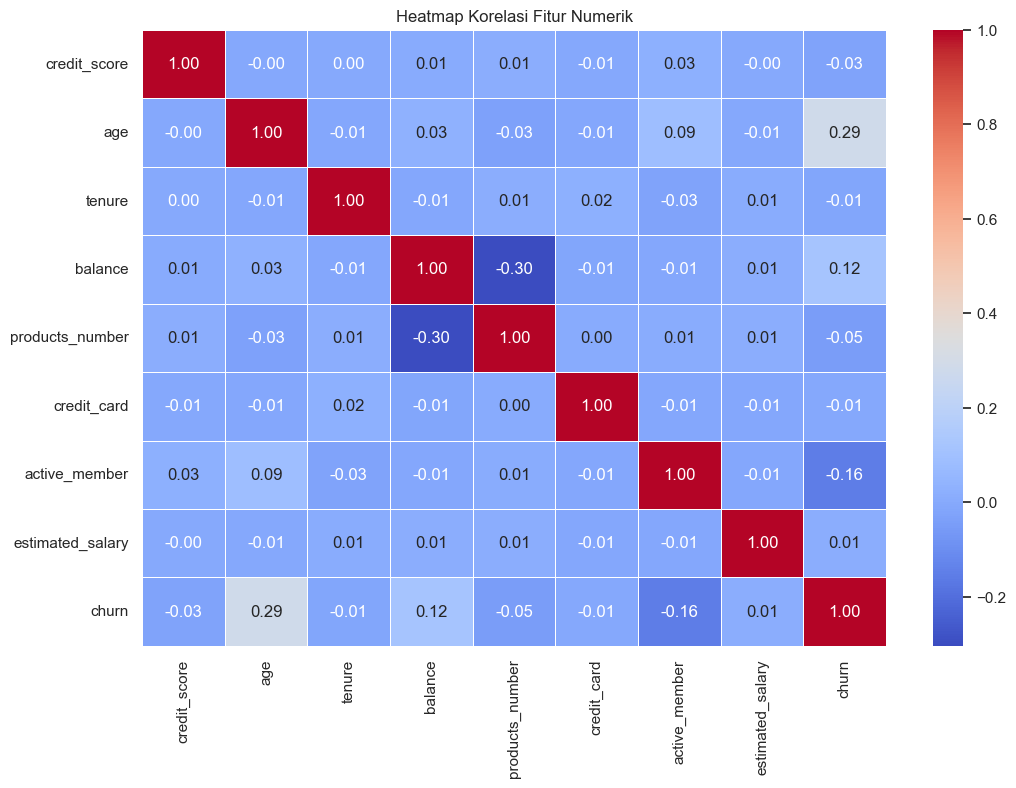

In [5]:
# Memilih hanya kolom numerik untuk korelasi
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Membuat heatmap korelasi
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()

# Menggambar heatmap (kita hilangkan kolom ID karena tidak relevan)
if "customer_id" in correlation_matrix.columns:
    correlation_matrix = correlation_matrix.drop("customer_id", axis=0).drop(
        "customer_id", axis=1
    )

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

## 3. Data Preprocessing
Berdasarkan EDA, kita perlu melakukan beberapa hal sebelum melatih model:
1. **Menghapus kolom yang tidak relevan:** `customer_id` (dan mungkin nama, jika ada) tidak memiliki nilai prediktif.
2. **Encoding Data Kategorikal:** Algoritma ML hanya menerima angka. Kita ubah `gender` dan `country` (geografi) menggunakan One-Hot Encoding.
3. **Train-Test Split:** Membagi data menjadi data latih dan data uji.
4. **Feature Scaling (Normalisasi):** Sangat krusial untuk KNN karena KNN mengandalkan perhitungan jarak geometris.

In [6]:
# 1. Menghapus kolom yang tidak relevan
# Sesuaikan nama kolom dengan dataset Anda ('customer_id', 'RowNumber', dll)
cols_to_drop = ["customer_id"]
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 2. Memisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

# Mengidentifikasi kolom kategorikal dan numerik
categorical_features = [
    "country",
    "gender",
]  # Sesuaikan jika namanya 'Geography', 'Gender'
numeric_features = X.columns.drop(categorical_features)

# Menggunakan ColumnTransformer untuk memproses tipe data yang berbeda
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ]
)

# 3. Train-Test Split (80% latih, 20% uji)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Menerapkan Preprocessing (Fitur Scaling & Encoding)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Mengambil nama kolom baru setelah encoding
new_cat_columns = preprocessor.named_transformers_["cat"].get_feature_names_out(
    categorical_features
)
all_feature_names = list(numeric_features) + list(new_cat_columns)

print(f"Bentuk X_train setelah preprocessing: {X_train_processed.shape}")

Bentuk X_train setelah preprocessing: (8000, 11)


## 4. Model 1: K-Nearest Neighbors (KNN)
Kita akan mencari nilai $K$ (jumlah tetangga) yang optimal dengan mencoba beberapa nilai, lalu melatih model final.

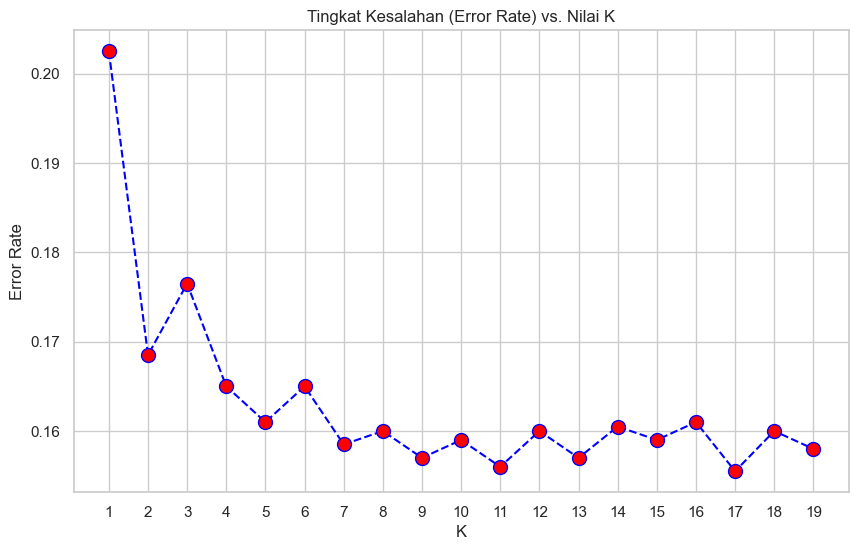

--- Laporan Klasifikasi KNN (K=5) ---
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1593
           1       0.67      0.42      0.51       407

    accuracy                           0.84      2000
   macro avg       0.77      0.68      0.71      2000
weighted avg       0.82      0.84      0.82      2000



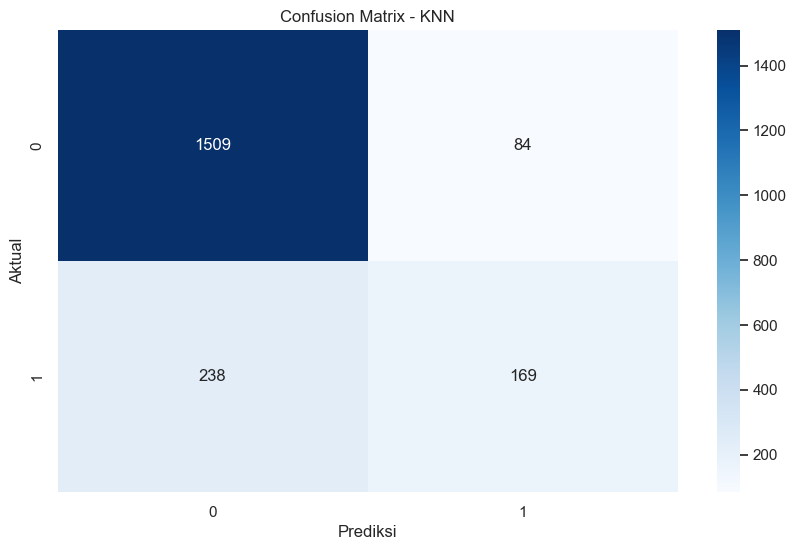

In [7]:
# Mencari nilai K yang optimal
error_rates = []

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_processed, y_train)
    pred_i = knn.predict(X_test_processed)
    error_rates.append(np.mean(pred_i != y_test))

# Visualisasi tingkat kesalahan untuk setiap K
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, 20),
    error_rates,
    color="blue",
    linestyle="dashed",
    marker="o",
    markerfacecolor="red",
    markersize=10,
)
plt.title("Tingkat Kesalahan (Error Rate) vs. Nilai K")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.xticks(range(1, 20))
plt.show()

# Mengambil K dengan error terendah (biasanya terlihat dari grafik, mari kita gunakan K=5 sebagai standar)
best_k = 5
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_processed, y_train)

# Prediksi dan Evaluasi
y_pred_knn = knn_model.predict(X_test_processed)

print(f"--- Laporan Klasifikasi KNN (K={best_k}) ---")
print(classification_report(y_test, y_pred_knn))

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## 5. Model 2: Regresi Logistik
Regresi logistik merupakan model probabilistik. Kita akan menggunakan bobot kelas (class weight) yang seimbang karena dataset kita imbalanced.

--- Laporan Klasifikasi Regresi Logistik ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



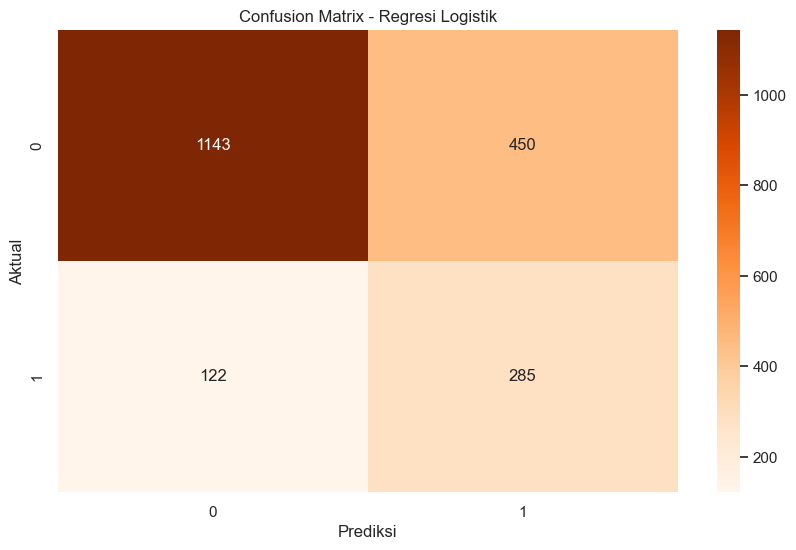

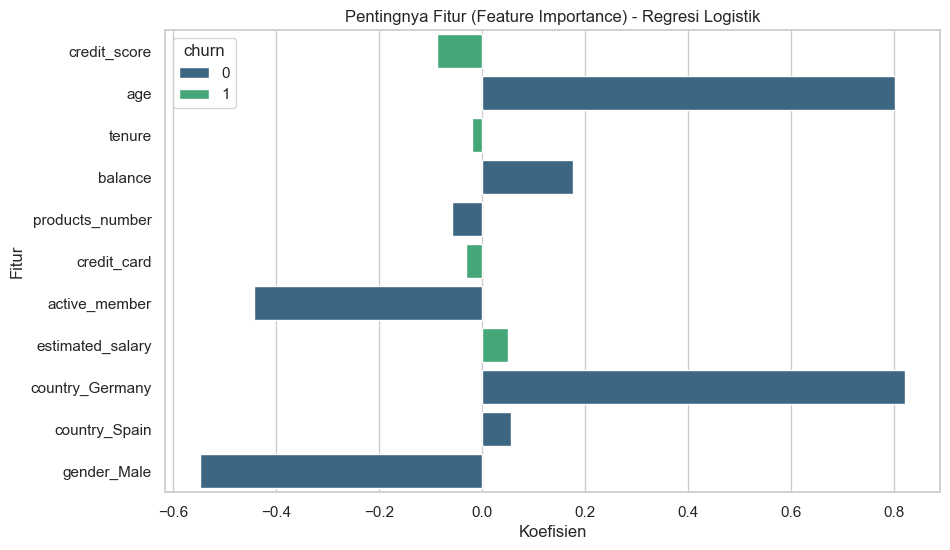

In [8]:
# Inisialisasi model (menggunakan class_weight='balanced' membantu menangani data yang tidak seimbang)
logreg_model = LogisticRegression(class_weight="balanced", random_state=42)

# Melatih model
logreg_model.fit(X_train_processed, y_train)

# Prediksi dan Evaluasi
y_pred_logreg = logreg_model.predict(X_test_processed)

print("--- Laporan Klasifikasi Regresi Logistik ---")
print(classification_report(y_test, y_pred_logreg))

sns.heatmap(
    confusion_matrix(y_test, y_pred_logreg), annot=True, fmt="d", cmap="Oranges"
)
plt.title("Confusion Matrix - Regresi Logistik")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

# Melihat pentingnya fitur (Feature Importance) dari koefisien Regresi Logistik
feature_importance = pd.DataFrame(
    {"Fitur": all_feature_names, "Koefisien": logreg_model.coef_[0]}
).sort_values(by="Koefisien", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Koefisien", y="Fitur", hue=y, data=feature_importance, palette="viridis")
plt.title("Pentingnya Fitur (Feature Importance) - Regresi Logistik")
plt.show()

## 6. Kesimpulan
* **Eksplorasi Data:** Kita telah melihat distribusi kelas target dan korelasi antar fitur. `age` dan `balance` biasanya memiliki pengaruh positif terhadap *churn*.
* **Performa KNN:** Mengandalkan pola kedekatan data. Akurasi bisa tinggi, namun sensitif terhadap *imbalanced data* (terlihat dari skor *recall* untuk kelas 1 yang mungkin rendah).
* **Performa Regresi Logistik:** Dengan pengaturan `class_weight='balanced'`, model ini seringkali lebih baik dalam mendeteksi nasabah yang benar-benar akan *churn* (Recall kelas 1 lebih tinggi), yang mana ini biasanya lebih diprioritaskan oleh pihak bank dibanding hanya mengejar akurasi umum.
* **Fitur Penting:** Dari grafik koefisien regresi logistik, kita bisa melihat faktor apa saja (seperti umur atau produk) yang paling mendorong nasabah untuk pergi atau bertahan.